In [13]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob, os
from collections import Counter

In [14]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
sudf = pd.read_csv('../data/Table_S1.csv')
sudf = sudf[['sample','cells_or_tissue_frac']].copy()


dfs = []
for i, r in cdf.iterrows():
    ch = r.dataset
    if not os.path.isfile(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt'):
        continue
        
    bdf = pd.read_csv(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt', sep='\t')
    dfs.append(bdf)
df = pd.concat(dfs)
cdf = cdf.merge(df, left_on='sample', right_on='sample', how='left')
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')
cdf = cdf.merge(sudf, left_on='sample', right_on='sample', how='left')
cdf['L_norm'] = cdf['nb_lib_L'] / cdf['cells_or_tissue_frac']
cdf.columns

Index(['sample', 'library_prep', 'dataset', 'group', 'subgroup', 'bam', 'gtf',
       'positions', 'probes', 'extra', 'fraction', 'reads', 'molecules',
       'reads_discarded', 'reads_excluded', 'downsampled_frac', 'saturation',
       'ztnb_rhat', 'ztnb_phat', 'ztnb_KS', 'ztnb_nll_per_mol',
       'ztnb_tail_mass', 'ztnb_error_flag', 'nb_lib_L',
       'nb_lib_saturation_MAE', 'nb_lib_recovery', 'countable_reads',
       'total_reads', 'full_saturation', 'full_reads', 'full_molecules',
       'spliced_reads', 'spliced_molecules', 'ambiguous_reads',
       'ambiguous_molecules', 'unspliced_reads', 'unspliced_molecules',
       'total_molecules', 'spliced_ztnb_rhat', 'spliced_ztnb_phat',
       'spliced_ztnb_KS', 'spliced_ztnb_nll_per_mol', 'spliced_ztnb_tail_mass',
       'spliced_ztnb_error_flag', 'spliced_nb_lib_L', 'ambiguous_ztnb_rhat',
       'ambiguous_ztnb_phat', 'ambiguous_ztnb_KS',
       'ambiguous_ztnb_nll_per_mol', 'ambiguous_ztnb_tail_mass',
       'ambiguous_ztnb_error_f

In [15]:
cdf['group'].value_counts()

group
PBMC_scrna         36
visium_hd          24
OvaryCA_CD45p      20
OvaryCA_CD45m      19
Heart              13
PBMC_scrna_flex    11
visium              9
Brain               7
Colon               6
Melanoma            4
Name: count, dtype: int64

In [16]:
from matplotlib.lines import Line2D
from matplotlib.colors import to_hex

#kdf3 = cdf[cdf['group'].str.contains('visium_hd')].copy()
#kdf3['marker'] = 'o'


kdf1 = cdf[cdf['sample'].str.startswith('PBMC_F')].copy()
#kdf1['marker'] = 'o'

kdf2 = cdf[cdf['group'].str.contains('Melanoma')].copy()
#kdf2['marker'] = 'D'

kdf3 = cdf[cdf['group'].str.contains('PBMC')].copy()
#kdf3['marker'] = 'o'


kdf4 = cdf[cdf['group'].str.contains('OvaryCA')].copy()
#kdf4['marker'] = 'o'
#kdf4.loc[kdf4['group'].str.contains('CD45p'), 'marker'] = '^'

#kdf4['color'] = to_hex(plt.cm.Set1.colors[0])
#kdf4.loc[kdf4['group'].str.contains('CD45p'), 'color'] = to_hex(plt.cm.Set1.colors[1])

markers_map = {
    "PBMC_scrna": "o",
    "PBMC_scrna_flex": "o",
    "visium_hd": "s",
    "OvaryCA_CD45p": "^",
    "OvaryCA_CD45m": "v",
    "Heart": "P",
    "visium": "X",
    "Brain": "D",
    "Colon": "h",
    "Melanoma": "*",
}

sdf = cdf[~cdf['group'].str.contains('visium')].sort_values('order')
sdf['marker'] = 'o'

marker_labels = {}
for g, t in zip(sdf['group'], sdf['group_title']):
    marker_labels[g] = t

library_prep_colors = {}
library_prep_labels = {}
for l, c, s in zip(sdf['library_prep'].values, sdf['color'].values, sdf['subgroup_title'].values):
    library_prep_colors[l] = c
    library_prep_labels[l] = s

0.8978512222499999 0.011878636890582652
Merged 11301.40597 590.9591582398151
Poly(A) 6257.773282499999 278.37440788824966
Random Hexamer 5191.74023475 561.4608707336504


,sample,primer_mode,cells,total_reads,total_molecules,saturation,ztnb_rhat,ztnb_phat,ztnb_KS,nb_lib_L,saturation_mae,nb_lib_L_per_cell
1,B2-PA-F1A,Merged,21579,233318097,117428592,49.670174,0.899904,0.487497,0.003641,2.466195e+08,0.070773,11428.682390
2,B2-PA-F1B,Merged,15412,161019667,80974574,49.711377,0.896169,0.486473,0.003614,1.702101e+08,0.099222,11043.998920
3,B2-PA-F5A,Merged,21044,213267348,107374680,49.652546,0.909109,0.489168,0.003671,2.246408e+08,0.063001,10674.816200
4,B2-PA-F5B,Merged,17243,197289553,99284804,49.675590,0.905922,0.488420,0.003669,2.079183e+08,0.070186,12058.126370
6,B2-PA-F1A,Poly(A),21579,121496182,60758823,49.991167,0.882615,0.481431,0.003804,1.277964e+08,0.087324,5922.259414
7,B2-PA-F1B,Poly(A),15412,93708551,46915456,49.934712,0.876073,0.480921,0.003791,9.910142e+07,0.062979,6430.146327
8,B2-PA-F5A,Poly(A),21044,122851354,61544859,49.902987,0.889239,0.483408,0.003805,1.292790e+08,0.057437,6143.272985
9,B2-PA-F5B,Poly(A),17243,107393942,53714841,49.983360,0.888417,0.482463,0.003862,1.126902e+08,0.076195,6535.414404
11,B2-PA-F1A,Random Hexamer,21579,112860648,57457785,49.089620,0.900535,0.493452,0.003523,1.220859e+08,0.053214,5657.625051
12,B2-PA-F1B,Random Hexamer,15412,68012924,34586099,49.147755,0.903598,0.493362,0.003342,7.329666e+07,0.089343,4755.817733


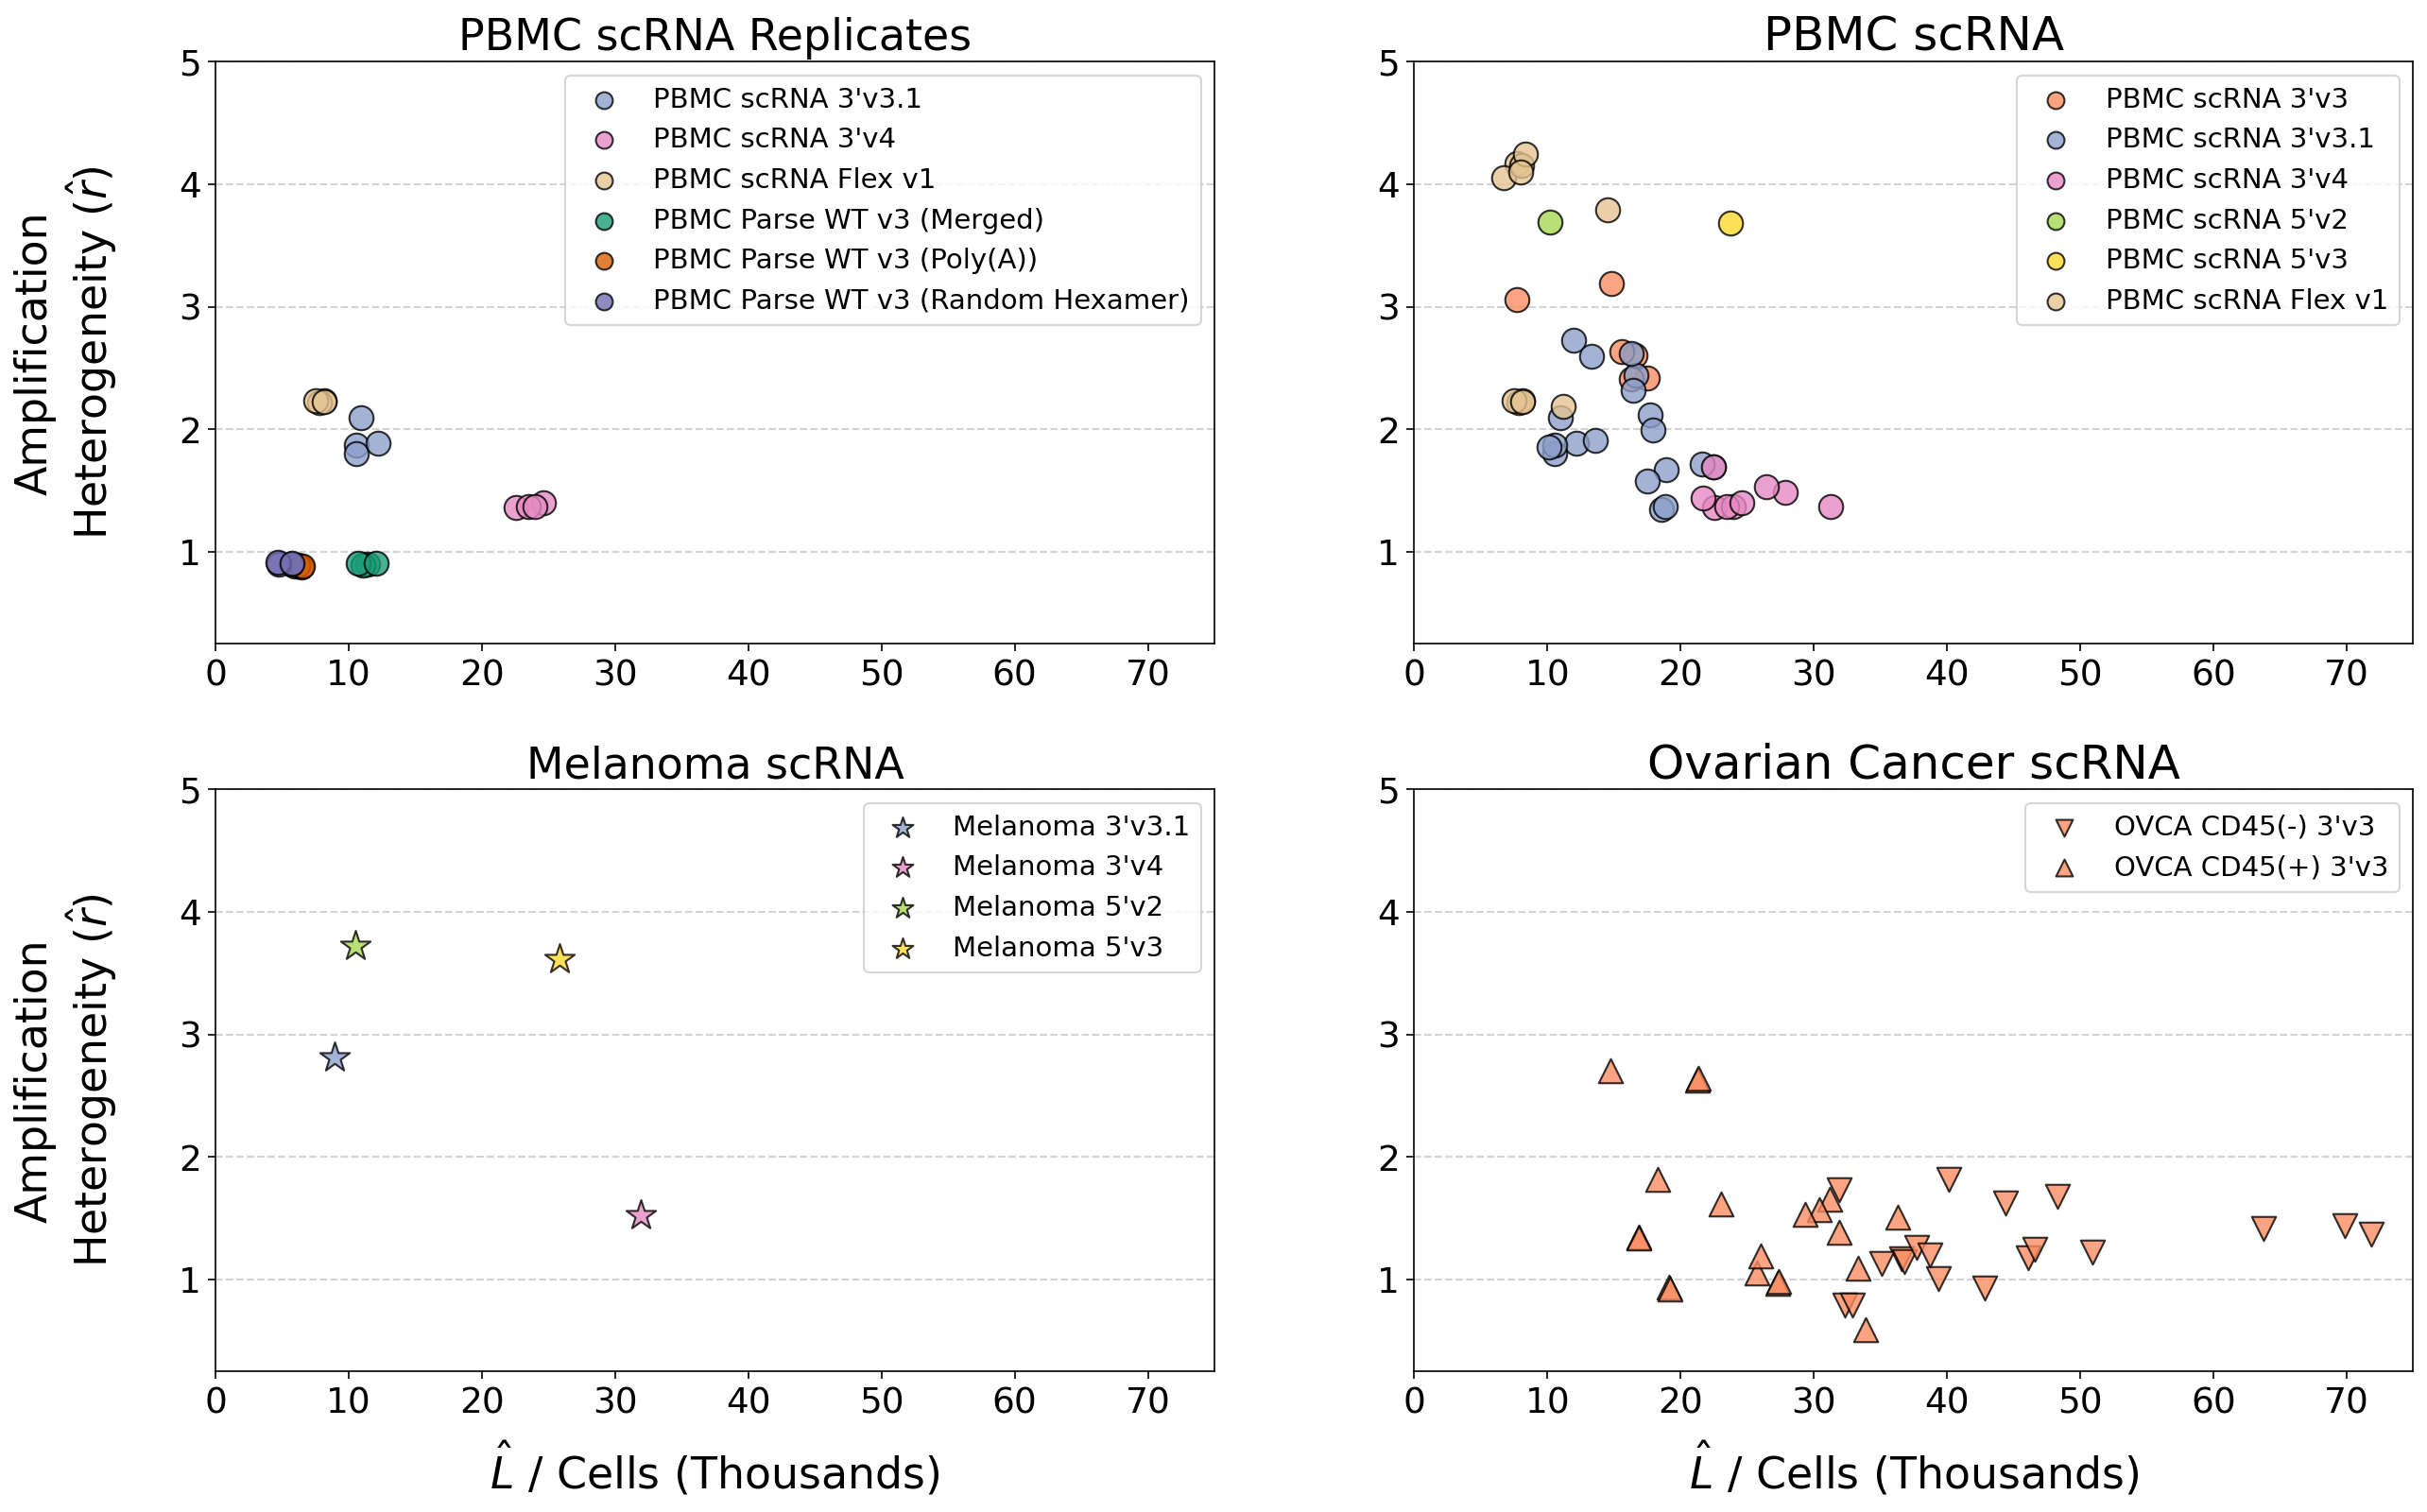

In [32]:
fig, axs = pl.figax(2, 2, h=6, w=10)
axs = axs.flatten()
fig.subplots_adjust(wspace=0.2, hspace=0.25)

for i, (kdf, ms) in enumerate(zip((kdf1, kdf3, kdf2, kdf4), (150, 150, 250, 150))):
    kdf = kdf.sort_values('order')
    seen = set()

    
    for s in kdf.itertuples():
        if np.isnan(s.ztnb_phat):
            continue
        title = s.title

        lab = '_'
        if title not in seen:
            seen.add(title)
            lab = title
            
        axs[i].scatter(s.L_norm/1000, s.ztnb_rhat, s=ms, color=s.color, label=lab, 
                       edgecolor='k', lw=1, alpha=0.8, marker=markers_map[s.group])
    if i == 0:
        parse_df = pd.read_csv('../Figures/Table S2.csv')
        parse_df = parse_df[parse_df['sample'] != 'full']
        print(parse_df['ztnb_rhat'].mean(), parse_df['ztnb_rhat'].std())

        for (p, g), col in zip(parse_df.groupby('primer_mode'), plt.cm.Dark2.colors):
            print(p, g['nb_lib_L_per_cell'].mean(), g['nb_lib_L_per_cell'].std())

            axs[i].scatter(g['nb_lib_L_per_cell']/1000, g['ztnb_rhat'],  s=ms, color=col, 
                       edgecolor='k', lw=1, alpha=0.8, marker=markers_map[s.group], label=f'PBMC Parse WT v3 ({p})')
        display(parse_df)
        

for ax in axs:
    #ax.set_xscale('log')
    ax.set_ylim(0.25, 5)
    ax.set_xlim(0, 75)
    #ax.set_xlim(5 * 10**3, 10**5)
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)

    ax.tick_params(axis='both', labelsize=18)
    ax.tick_params(axis='both', which='both', length=4)

axs[0].set_title('PBMC scRNA Replicates', fontsize=22)
axs[2].set_title('Melanoma scRNA', fontsize=22)
for ax in axs[2:]:
    ax.set_xlabel('$\\hat{L}$ / Cells (Thousands)', fontsize=22, labelpad=10)

axs[1].set_title('PBMC scRNA', fontsize=24)
axs[3].set_title('Ovarian Cancer scRNA', fontsize=24)
for ax in axs:
    ax.legend(markerscale=0.7, fontsize=14)
#axs[0].legend(markerscale=0.7, fontsize=14)
#axs[1].legend(markerscale=0.7, fontsize=14)
#axs[2].legend(markerscale=0.7, fontsize=14)
#axs[3].legend(markerscale=0.7, fontsize=14)

axs[0].set_ylabel('Amplification\nHeterogeneity ($\\hat{r}$)', fontsize=22, labelpad=30)
axs[2].set_ylabel('Amplification\nHeterogeneity ($\\hat{r}$)', fontsize=22, labelpad=30)

fig.savefig('../Figures/Figure 3C-F rhat Lhat grid.svg', bbox_inches='tight')

rec 50 39.42657517799184 70.32292214198131
rec 70 57.45675916839834 89.5745175071029
cost 50 7.821827601076269 80.22802200156738
cost 70 16.857722151550018 182.68746558920145


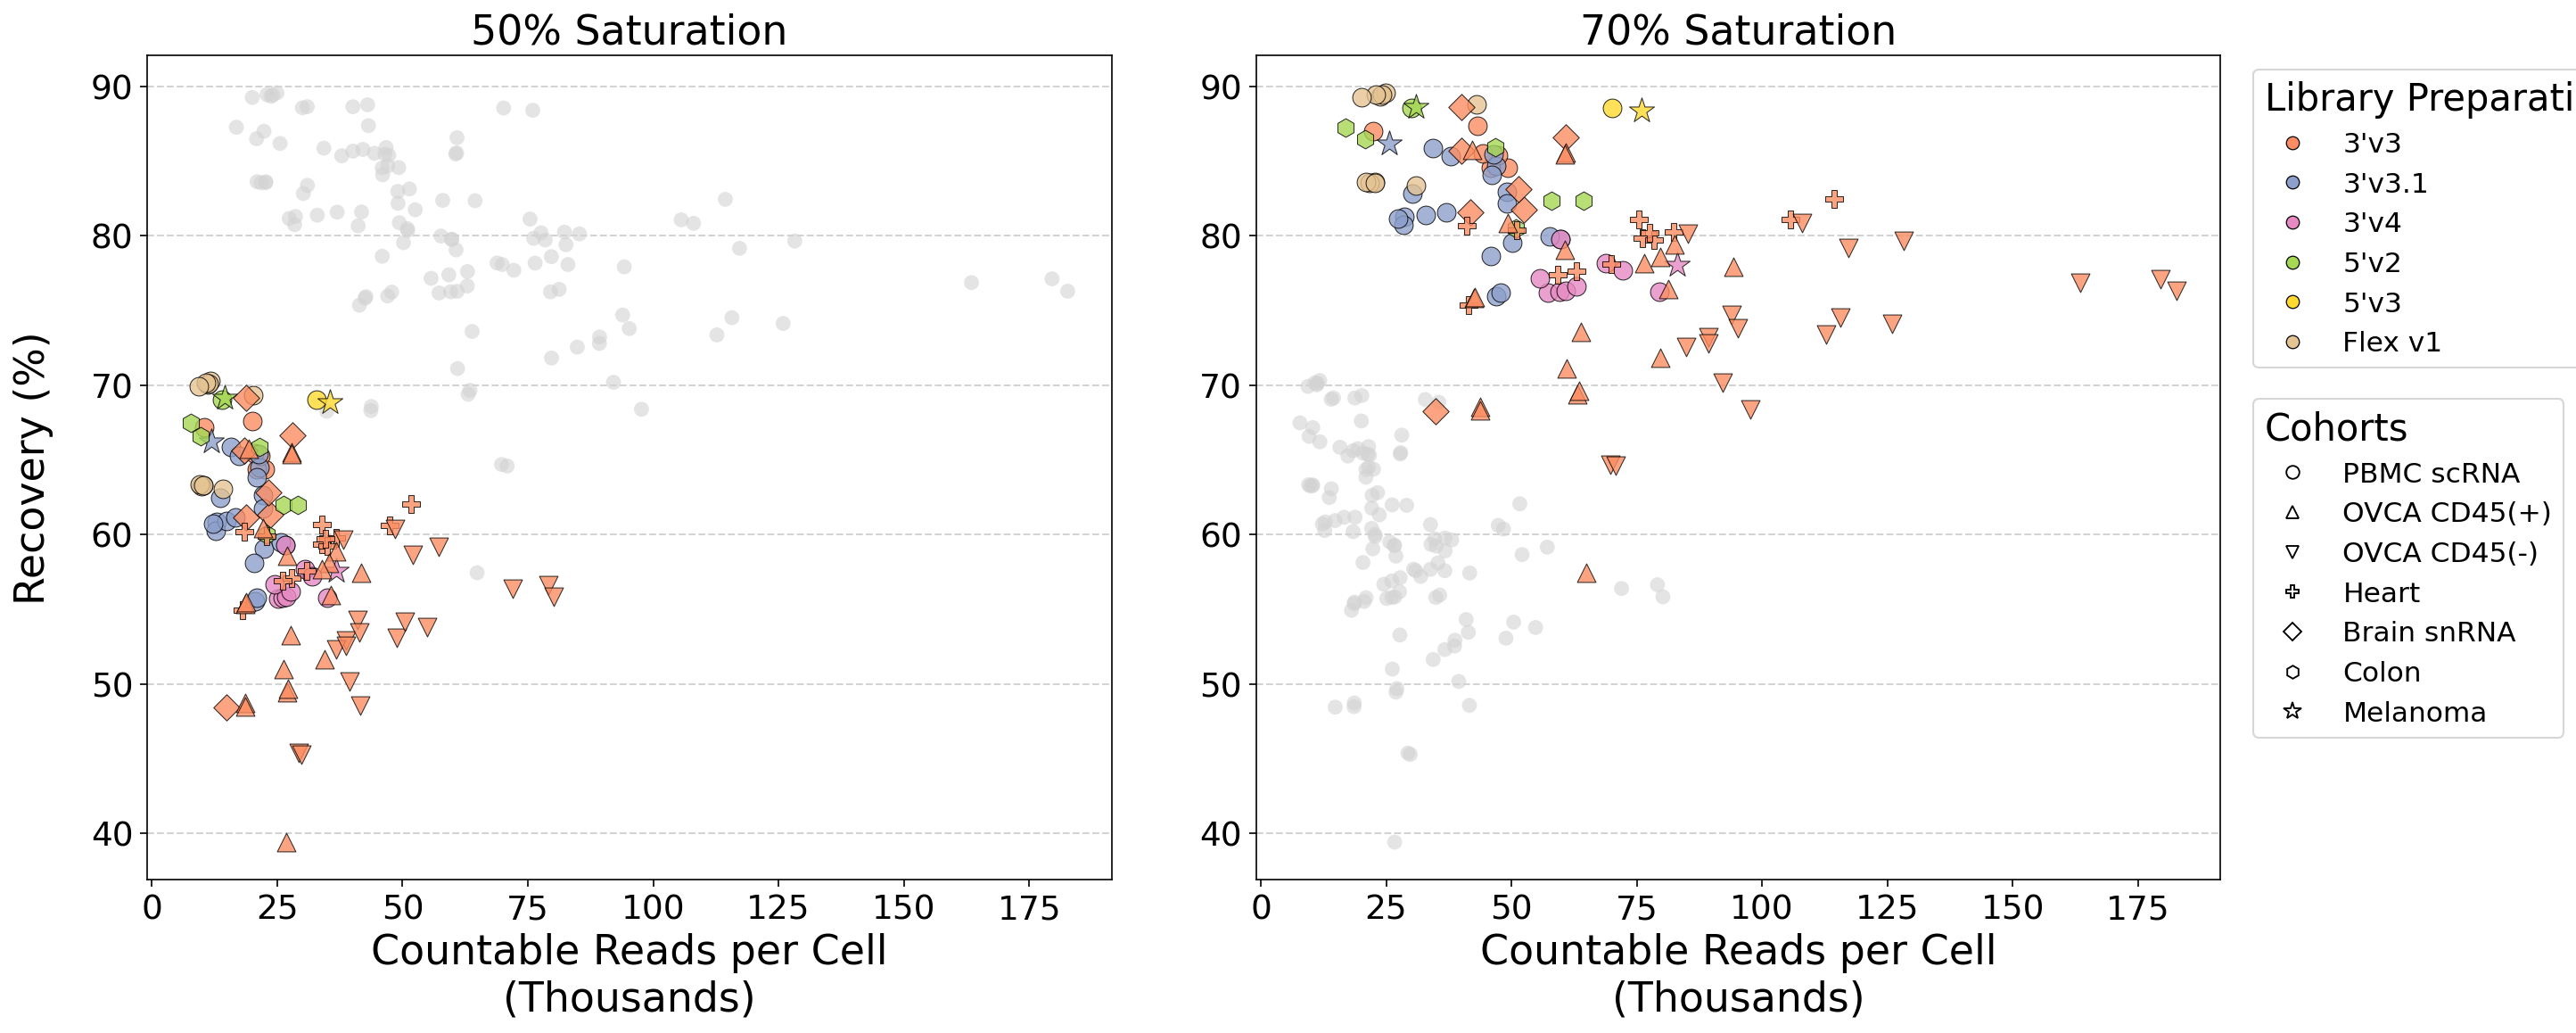

In [11]:
fig, axs = pl.figax(1, 2, w=10, h=8)
fig.subplots_adjust(wspace=0.15)
sats = [50, 70]


sdf = cdf[~cdf['group'].str.contains('visium')].sort_values('order')
sdf['marker'] = 'o'

#sdf.loc[sdf['group'].str.contains('CD45p'), 'color'] = to_hex(plt.cm.Set1.colors[1])
#sdf.loc[sdf['group'].str.contains('CD45m'), 'color'] = to_hex(plt.cm.Set1.colors[0])
#sdf.loc[sdf['group'].str.contains('Heart'), 'color'] = to_hex(plt.cm.Set1.colors[3])
#sdf.loc[sdf['group'].str.contains('Brain'), 'color'] = to_hex(plt.cm.Set1.colors[4])
#sdf.loc[sdf['group'].str.contains('Colon'), 'color'] = to_hex(plt.cm.Set1.colors[2])
seen = set()

frecs = {50:[], 70:[]}
fcost = {50:[], 70:[]}

for s in sdf.itertuples():
    if np.isnan(s.ztnb_phat):
        continue
    title = s.title

    lab = '_'
    if title not in seen:
        seen.add(title)
        lab = title
    ff = fit.NBLibFit(rhat=s.ztnb_rhat, phat=s.ztnb_phat, L=s.nb_lib_L)
    reads = ff.reads_for_saturation(sats)
    nreads = (reads / s.cells_or_tissue_frac) 

    recs = ff.predict_recovery(reads)
    frecs[50].append(recs[0])
    frecs[70].append(recs[1])
    fcost[50].append(nreads[0])
    fcost[70].append(nreads[1])
    ms = 100 if 'Melanoma' not in lab else 200
    axs[0].scatter(nreads[0]/1000, recs[0], color=s.color, edgecolor='k', lw=0.5, s=ms, alpha=0.8, 
                   marker=markers_map[s.group], zorder=5, label=lab, rasterized=True)
    axs[1].scatter(nreads[0]/1000, recs[0], color='lightgray', edgecolor='none', lw=0.5, s=65, alpha=0.6, marker=s.marker, zorder=4, rasterized=True)

    axs[1].scatter(nreads[1]/1000, recs[1], color=s.color, edgecolor='k', lw=0.5, s=ms, alpha=0.8, 
                   marker=markers_map[s.group], zorder=5, label=lab, rasterized=True)
    axs[0].scatter(nreads[1]/1000, recs[1], color='lightgray', edgecolor='none', lw=0.5, s=65, alpha=0.6, marker=s.marker, zorder=4, rasterized=True)

axs[0].set_ylabel('Recovery (%)', fontsize=22, labelpad=20)

for ax in axs:
    #ax.set_ylim(25, 90)
    #ax.set_xlim(1, 150)
    #ax.set_xlim(0.8 * 10**3, 5 * 10**5)
    #ax.set_xscale('log')
    ax.set_xlabel('Countable Reads per Cell\n(Thousands)', fontsize=22)
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)

    ax.tick_params(axis='both', labelsize=18)
    ax.tick_params(axis='both', which='both', length=4)
axs[0].set_title('50% Saturation', fontsize=22)
axs[1].set_title('70% Saturation', fontsize=22)
#axs[1].legend(loc = 'upper left', bbox_to_anchor=(1.02, 1), fontsize=15)

print('rec', 50, min(frecs[50]), max(frecs[50]))
print('rec', 70, min(frecs[70]), max(frecs[70]))

print('cost', 50, min(fcost[50])/1e3, max(fcost[50])/1e3)
print('cost', 70, min(fcost[70])/1e3, max(fcost[70])/1e3)


library_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.6,
        markersize=7,
        label=library_prep_labels[library_prep],
    )
    for library_prep, color in library_prep_colors.items()
]

lgd1 = axs[1].legend(
    handles=library_handles,
    title="Library Preparation",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    fontsize=15, title_fontsize=20, 
    alignment="left"
)
ax.add_artist(lgd1)

cohort_order = [
    "PBMC_scrna",
    "OvaryCA_CD45p",
    "OvaryCA_CD45m",
    "Heart",
    "Brain",
    "Colon",
    "Melanoma",
]


cohort_handles = [
    Line2D(
        [0],
        [0],
        marker=markers_map[group],
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=0.9,
        markersize=(7 if 'Melanoma' not in marker_labels[group] else 10),
        label=marker_labels[group],
    )
    for group in cohort_order
]

lgd2 = axs[1].legend(
    handles=cohort_handles,
    title="Cohorts",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.6),
    fontsize=15, title_fontsize=20, 
    alignment="left"
)

fig.savefig('../Figures/Figure 3G Costs.svg', bbox_inches='tight', bbox_extra_artists=(lgd1, lgd2))


rec 50 55.53301384558886 73.9266325909753
rec 70 75.97459465223768 92.26291024577088
cost 50 60.615239923021406 2199.442730243926
cost 70 128.84672762899274 4717.716571994799
real cost 50 36.05527088012971 1539.6099111707479
real cost 70 76.27586282889268 3302.401600396359


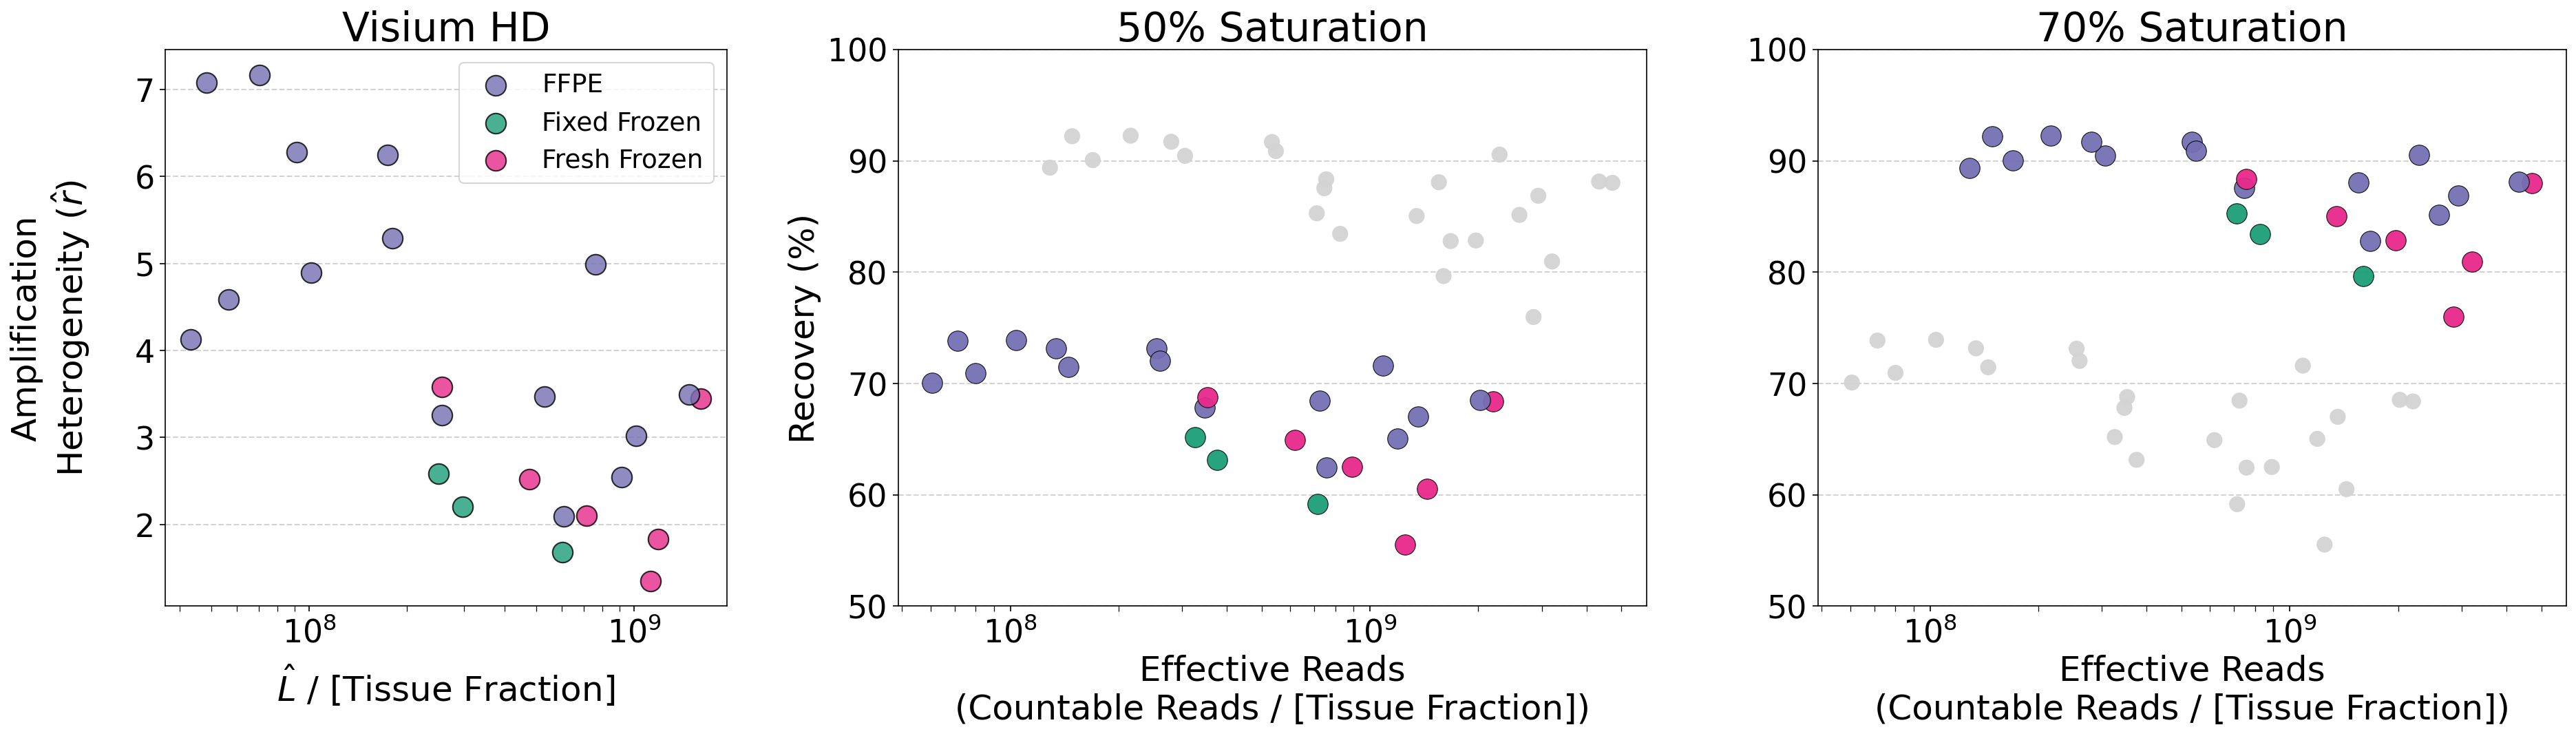

In [12]:
vdf = cdf[cdf['group'] == 'visium_hd']
fig, axs = pl.figax(1, 3, h=7, w=10, width_ratios=[3, 4, 4])
fig.subplots_adjust(wspace=0.25, hspace=0.3)
seen = set()
frecs = {50:[], 70:[]}
fcost = {50:[], 70:[]}
freal = {50:[], 70:[]}
for s in vdf.itertuples():
    if np.isnan(s.ztnb_phat):
        continue
    title = s.subgroup_title

    lab = '_'
    if title not in seen:
        seen.add(title)
        lab = title
    axs[0].scatter(s.L_norm, s.ztnb_rhat, s=200, color=s.color, label=lab, edgecolor='k', lw=1, alpha=0.8, marker='o')


    lab = '_'
    if title not in seen:
        seen.add(title)
        lab = title
    ff = fit.NBLibFit(rhat=s.ztnb_rhat, phat=s.ztnb_phat, L=s.nb_lib_L)
    reads = ff.reads_for_saturation(sats)
    nreads = (reads / s.cells_or_tissue_frac) 

    recs = ff.predict_recovery(reads)
    frecs[50].append(recs[0])
    frecs[70].append(recs[1])
    fcost[50].append(nreads[0])
    fcost[70].append(nreads[1])
    freal[50].append(reads[0])
    freal[70].append(reads[1])
    axs[1].scatter(nreads[0], recs[0], color=s.color, edgecolor='k', lw=0.5, s=200, alpha=0.95, marker='o', zorder=5, label=lab)
    axs[2].scatter(nreads[0], recs[0], color='lightgray', edgecolor='none', lw=0.5, s=125, alpha=0.95, marker='o', zorder=4)
    axs[2].scatter(nreads[1], recs[1], color=s.color, edgecolor='k', lw=0.5, s=200, alpha=0.95, marker='o', zorder=5)
    axs[1].scatter(nreads[1], recs[1], color='lightgray', edgecolor='none', lw=0.5, s=125, alpha=0.95, marker='o', zorder=4)

print('rec', 50, min(frecs[50]), max(frecs[50]))
print('rec', 70, min(frecs[70]), max(frecs[70]))

print('cost', 50, min(fcost[50])/1e6, max(fcost[50])/1e6)
print('cost', 70, min(fcost[70])/1e6, max(fcost[70])/1e6)
print('real cost', 50, min(freal[50])/1e6, max(freal[50])/1e6)
print('real cost', 70, min(freal[70])/1e6, max(freal[70])/1e6)

for ax in axs:

    ax.set_xscale('log')
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=22)
    ax.tick_params(axis='both', which='both', length=4)
axs[1].set_ylim(50, 100)
axs[2].set_ylim(50, 100)
axs[1].set_xlabel('Effective Reads\n(Countable Reads / [Tissue Fraction])', fontsize=24)
axs[2].set_xlabel('Effective Reads\n(Countable Reads / [Tissue Fraction])', fontsize=24)

axs[0].set_xscale('log')
axs[0].set_xlabel('$\\hat{L}$ / [Tissue Fraction]', fontsize=24, labelpad=10)
axs[0].set_ylabel('Amplification\nHeterogeneity ($\\hat{r}$)', fontsize=24, labelpad=30)
axs[1].set_title('50% Saturation', fontsize=28)
axs[2].set_title('70% Saturation', fontsize=28)
axs[1].set_ylabel('Recovery (%)', fontsize=24)
axs[0].set_title('Visium HD', fontsize=28)
axs[0].legend(loc = 'upper right', fontsize=18)
fig.savefig('../Figures/Figure 3AB Costs.svg', bbox_inches='tight')

In [8]:
for s, g in kdf1.groupby('subgroup'):
    print(f"{s}, {g['ztnb_rhat'].mean():.2f} +/- {g['ztnb_rhat'].std():.2f}")

10X_3p_v31, 1.92 +/- 0.13
10X_3p_v4, 1.38 +/- 0.02
10X_flex_v1, 2.23 +/- 0.01


In [9]:
for s, g in kdf1.groupby('subgroup'):
    print(f"{s}, {g['L_norm'].mean():.2f} +/- {g['L_norm'].std():.2f}")

10X_3p_v31, 11062.24 +/- 754.53
10X_3p_v4, 23642.77 +/- 870.52
10X_flex_v1, 7911.48 +/- 302.82
